<a href="https://colab.research.google.com/github/nadilHesara/langid_experiments/blob/main/LangID.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

#Sinhala-Script LangID
classify a sentence written in the Sinhala script as `sinhala`, `pali`, or `sanskrit`.

In [36]:

%pip install -q fasttext-wheel langdetect scikit-learn pandas matplotlib joblib

import os, re, random, unicodedata
import numpy as np
import pandas as pd

SEED = 42
random.seed(SEED); np.random.seed(SEED)

CORE_LABELS = ["sinhala", "pali", "sanskrit"]

OUTPUT_DIR = "/content/drive/MyDrive/SSLI/processed"


     ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 981.5/981.5 kB 13.3 MB/s eta 0:00:00
  Preparing metadata (setup.py) ... done
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 4.6/4.6 MB 89.5 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 314.2/314.2 kB 22.5 MB/s eta 0:00:00


##Raw data loading

###sinhala paali parallel corpus

In [37]:
from google.colab import drive
drive.mount('/content/drive')

import pandas as pd

path = "/content/drive/MyDrive/SSLI/raw_data/sinhala_paali_parallel_corpus/output.tsv"

df = pd.read_csv(path, sep="\t")
print(df.shape)
print(df.columns.tolist())
df.head()

Drive already mounted at /content/drive; to attempt to forcibly remount, call drive.mount("/content/drive", force_remount=True).
(28395, 2)
['pali_text', 'sinhala_text']


,pali_text,sinhala_text
0,එවං මෙ සුතං - එකං සමයං භගවා අන්තරා ච රාජගහං අන...,මා විසින් මෙසේ අසනලදී. (නොහොත් මගේ ඇසීම මෙලෙසය...
1,අථ ඛො භගවා අම්බලට්ඨිකායං රාජාගාරකෙ එකරත්තිවාසං...,එවිට භාග්‍යවතුන් වහන්සේ අම්බලට්ඨිකා උයනෙහි රජු...
2,අථ ඛො සම්බහුලානං භික්ඛූනං රත්තියා පච්චූසසමයං ප...,එකල රෑ පාන්දරින් මණ්ඩලමාල නම් රැස්වීම් ශාලාවෙහ...
3,අථ ඛො භගවා තෙසං භික්ඛූනං ඉමං සඞ්ඛියධම්මං විදිත...,එකල්හි භාග්‍යවතුන් වහන්සේ භික්ෂූන්ගේ මේ කථාව ද...
4,"‘‘මමං වා, භික්ඛවෙ, පරෙ අවණ්ණං භාසෙය්‍යුං, ධම්ම...","“මහණෙනි, අනුන් මාගේ හෝ නුගුණ කියද්ද, ධර්මය ගැන..."


###Pali documents(SiDiaC-v2)

In [38]:
import os

folder = "/content/drive/.shortcut-targets-by-id/1gPCbEcE9ztxyuWFqpVtSSNpel4wklH_g/SSLI/raw_data/doc/paali"

txt_files = [f for f in os.listdir(folder) if f.endswith(".txt")]
print(f"Found {len(txt_files)} files:")
for f in txt_files:
    print(f)

Found 15 files:
අධිමාස දීපනය.txt
බුද්ධ සික්ඛා.txt
මහාවංස ටීකා.txt
සුමංගල විලාසිනි නාමා දීඝනිකාය අට්ඨකථා.txt
සාදුපත්ථපුරණී.txt
සාදුජනපපසාදිනී.txt
සමෙමාහනාසිනී.txt
මහාරූපසිද්ධි.txt
මොග්ගලලායනව්_යාකරණං.txt
අධිකරණ විභාග සංඝෝ.txt
මාහාවංසො (තුතියෝ භාගෝ).txt
ප්_රපංච සුදනීනාම මජ්ජිම නිකාය අට්ඨකථා හෙවත් මැදුම් සඟි අටුවාව.txt
ධම්මපදට්ඨ කථා - දුතියො භාගො.txt
දීපවංසෝ.txt
ජාතකට්ඨකථා.txt


In [39]:
import re, pandas as pd

label_map = {
    "අධිමාස": "pali", "කුදුසික": "pali", "ටීකා": "pali",
    "සුමංගල": "pali", "සාදුපත්ථ": "pali", "සාදුජනප": "pali",
    "සමෙමාහන": "pali", "බුද්ධ සික්ඛා": "pali", "මහාරූපසිද්ධි": "pali",
    "ග්ගලලායන": "pali", "අධිකරණ": "pali", "මාහාවංසො": "pali",
    "ප්_රපංච": "pali", "ප්රපංච": "pali",
    "පබ්බතූපම": "pali_then_sinhala",
    "ධම්මපදට්ඨ": "pali", "දීපවංසෝ": "pali", "ජාතකට්ඨකථා": "pali",
    "කවච": "sanskrit_from_line40",
    "චරියා": "EXCLUDE_COPYRIGHT",
}

import unicodedata

def normalize(s):
    return unicodedata.normalize("NFC", s)

def find_label(filename):
    filename_norm = normalize(filename)
    for key, val in label_map.items():
        if normalize(key) in filename_norm:
            return val
    return "UNKNOWN"

rows = []
skipped = []

for fname in txt_files:
    label = find_label(fname)
    book_title = fname.replace(".txt", "")

    if label in ("EXCLUDE_COPYRIGHT", "UNKNOWN"):
        skipped.append((fname, label))
        continue

    with open(os.path.join(folder, fname), encoding="utf-8") as f:
        text = f.read()

    lines = [l.strip() for l in text.split("\n")]
    lines = [l for l in lines if len(l) > 5 and not re.fullmatch(r"[\d\.\s]+", l)]

    if label == "pali_then_sinhala":
        skipped.append((fname, "needs manual pali/sinhala split"))
        continue

    if label == "sanskrit_from_line40":
        lines = lines[39:]
        label = "sanskrit"

    for sent in lines:
        rows.append({
            "text": sent,
            "label": label,
            "source": "SiDiaC-v2",
            "subcorpus": book_title,
            "group_id": f"sidiac2_{book_title}"
        })

sidiac_df = pd.DataFrame(rows)
print(sidiac_df.shape)
print(sidiac_df["label"].value_counts())
print("\nSkipped/flagged:")
for s in skipped:
    print(s)

(2929, 5)
label
pali    2929
Name: count, dtype: int64

Skipped/flagged:


####Sanskrit documents(SiDiaC-v2)

In [40]:
sanskrit_folder = "/content/drive/.shortcut-targets-by-id/1gPCbEcE9ztxyuWFqpVtSSNpel4wklH_g/SSLI/raw_data/doc/sasnkrit"

sanskrit_rows = []
for fname in os.listdir(sanskrit_folder):
    if not fname.endswith(".txt"):
        continue
    with open(os.path.join(sanskrit_folder, fname), encoding="utf-8") as f:
        text = f.read()
    lines = [l.strip() for l in text.split("\n")]
    lines = lines[39:]  # skip 39-lines
    lines = [l for l in lines if len(l) > 5 and not re.fullmatch(r"[\d\.\s]+", l)]
    book = fname.replace(".txt", "")
    for sent in lines:
        sanskrit_rows.append({
            "text": sent, "label": "sanskrit", "source": "SiDiaC-v2",
            "subcorpus": book, "group_id": f"sidiac2_{book}",
        })

sanskrit_df = pd.DataFrame(sanskrit_rows)
sidiac_df = pd.concat([sidiac_df, sanskrit_df], ignore_index=True)
print(sidiac_df["label"].value_counts())


label
pali        2929
sanskrit     101
Name: count, dtype: int64


###Reshape parallel corpus to long form

In [41]:
pali_rows = df[["pali_text"]].rename(columns={"pali_text": "text"})
pali_rows["label"] = "pali"

sinhala_rows = df[["sinhala_text"]].rename(columns={"sinhala_text": "text"})
sinhala_rows["label"] = "sinhala"

parallel_long = pd.concat([pali_rows, sinhala_rows], ignore_index=True)
parallel_long["source"] = "pali-sinhala-parallel"
parallel_long["subcorpus"] = "parallel_corpus"
parallel_long["group_id"] = "parallel_" + parallel_long.index.astype(str)

print(parallel_long.shape)
print(parallel_long["label"].value_counts())

(56790, 5)
label
pali       28395
sinhala    28395
Name: count, dtype: int64


##Build unified dataset(clean + dedup)

In [42]:
def clean_text(s):
    s = str(s)
    s = re.sub(r"<[^>]+>", " ", s)      # strip markup/OCR tags like <psi>, <eos>
    s = re.sub(r"\s+", " ", s).strip()
    return s

unified = pd.concat([sidiac_df, parallel_long], ignore_index=True)
unified = unified.dropna(subset=["text"])
unified["text"] = unified["text"].map(clean_text)
unified = unified[unified["text"].str.len() > 0]

before = len(unified)
unified = unified.drop_duplicates(subset="text").reset_index(drop=True)
print(f"Removed {before - len(unified)} duplicate/empty sentences")

unified["id"] = range(len(unified))
unified = unified[["id", "text", "label", "source", "subcorpus", "group_id"]]
print(unified.shape)
print(unified["label"].value_counts())
unified.head()


Removed 3866 duplicate/empty sentences
(55954, 6)
label
pali        29317
sinhala     26536
sanskrit      101
Name: count, dtype: int64


,id,text,label,source,subcorpus,group_id
0,0,අධිමාසංදීපනි.,pali,SiDiaC-v2,අධිමාස දීපනය,sidiac2_අධිමාස දීපනය
1,1,නමො අද්වයවාදිනො සම්මා සම්බුද්ධස්ස.,pali,SiDiaC-v2,අධිමාස දීපනය,sidiac2_අධිමාස දීපනය
2,2,1 නමාමී බුද්ධං චතුසච්ච බුද්ධං,pali,SiDiaC-v2,අධිමාස දීපනය,sidiac2_අධිමාස දීපනය
3,3,"නමාමි ධම්මං අධිමොක්ඛ ධම්මං,",pali,SiDiaC-v2,අධිමාස දීපනය,sidiac2_අධිමාස දීපනය
4,4,නමාමි සංඝං හතපාප සංඝං,pali,SiDiaC-v2,අධිමාස දීපනය,sidiac2_අධිමාස දීපනය


In [43]:
print("Groups per label:")
print(unified.groupby("label")["group_id"].nunique())


Groups per label:
label
pali        26435
sanskrit        1
sinhala     26536
Name: group_id, dtype: int64


##Group-stratified split + save

In [44]:
from sklearn.model_selection import GroupShuffleSplit


def group_stratified_split(data, group_col, label_col, source_col="source", seed=42, min_groups_for_group_split=3):
    splits = {"train": [], "val": [], "test": []}

    for (label, source), sub in data.groupby([label_col, source_col]):
        n_groups = sub[group_col].nunique()

        if n_groups < min_groups_for_group_split:
            from sklearn.model_selection import train_test_split
            train, temp = train_test_split(sub, test_size=0.2, random_state=seed)
            val, test = train_test_split(temp, test_size=0.5, random_state=seed)
        else:
            gss1 = GroupShuffleSplit(n_splits=1, test_size=0.2, random_state=seed)
            train_idx, temp_idx = next(gss1.split(sub, groups=sub[group_col]))
            train = sub.iloc[train_idx]
            temp = sub.iloc[temp_idx]

            gss2 = GroupShuffleSplit(n_splits=1, test_size=0.5, random_state=seed)
            val_idx, test_idx = next(gss2.split(temp, groups=temp[group_col]))
            val = temp.iloc[val_idx]
            test = temp.iloc[test_idx]

        splits["train"].append(train)
        splits["val"].append(val)
        splits["test"].append(test)

    return {k: pd.concat(v, ignore_index=True) for k, v in splits.items()}

splits = group_stratified_split(unified, group_col="group_id", label_col="label", source_col="source")

for name, part in splits.items():
    print(f"\n--- {name} ---")
    print(part.groupby(["label", "source"]).size())


--- train ---
label     source               
pali      SiDiaC-v2                 2354
          pali-sinhala-parallel    21136
sanskrit  SiDiaC-v2                   80
sinhala   pali-sinhala-parallel    21228
dtype: int64

--- val ---
label     source               
pali      SiDiaC-v2                 158
          pali-sinhala-parallel    2642
sanskrit  SiDiaC-v2                  10
sinhala   pali-sinhala-parallel    2654
dtype: int64

--- test ---
label     source               
pali      SiDiaC-v2                 385
          pali-sinhala-parallel    2642
sanskrit  SiDiaC-v2                  11
sinhala   pali-sinhala-parallel    2654
dtype: int64


In [45]:
# Save the exact split so every model trains/tests on identical data (fair benchmark).
os.makedirs(OUTPUT_DIR, exist_ok=True)
unified.to_csv(f"{OUTPUT_DIR}/unified.csv", index=False)
for name, part in splits.items():
    part.to_csv(f"{OUTPUT_DIR}/{name}.csv", index=False)
    print(f"saved {name}: {len(part)} rows")

train, val, test = splits["train"], splits["val"], splits["test"]


saved train: 44798 rows
saved val: 5464 rows
saved test: 5692 rows


##Evaluation utilities(shared by every model)

In [46]:
from sklearn.metrics import accuracy_score, f1_score, classification_report, confusion_matrix
import matplotlib.pyplot as plt

RESULTS = []  # every model appends one row here -> the benchmark table

def evaluate_model(name, y_true, y_pred, note=""):
    y_true, y_pred = list(y_true), list(y_pred)
    acc = accuracy_score(y_true, y_pred)
    macro_f1 = f1_score(y_true, y_pred, labels=CORE_LABELS, average="macro", zero_division=0)
    per_class = f1_score(y_true, y_pred, labels=CORE_LABELS, average=None, zero_division=0)
    row = {"model": name, "accuracy": round(acc, 3), "macro_F1": round(macro_f1, 3)}
    for lab, f in zip(CORE_LABELS, per_class):
        row[f"F1_{lab}"] = round(float(f), 3)
    if note:
        row["note"] = note
    RESULTS.append(row)
    print(f"\n=== {name} ===")
    print(classification_report(y_true, y_pred, labels=CORE_LABELS, zero_division=0))
    return row

def show_confusion(name, y_true, y_pred):
    labels = CORE_LABELS + (["other"] if "other" in set(y_pred) else [])
    cm = confusion_matrix(y_true, y_pred, labels=labels)
    cm_df = pd.DataFrame(cm, index=[f"true_{l}" for l in labels],
                             columns=[f"pred_{l}" for l in labels])
    print(f"\nConfusion matrix — {name}")
    print(cm_df)
    try:
        fig, ax = plt.subplots(figsize=(4.5, 4))
        ax.imshow(cm, cmap="Blues")
        ax.set_xticks(range(len(labels))); ax.set_xticklabels(labels, rotation=45, ha="right")
        ax.set_yticks(range(len(labels))); ax.set_yticklabels(labels)
        for i in range(len(labels)):
            for j in range(len(labels)):
                ax.text(j, i, cm[i, j], ha="center", va="center")
        ax.set_xlabel("predicted"); ax.set_ylabel("true"); ax.set_title(name)
        plt.tight_layout(); plt.show()
    except Exception as e:
        print("(plot skipped:", e, ")")


##Model 1 - char n-gram + Logistic Regression(baseline)


=== char n-gram + LogReg (ours) ===
              precision    recall  f1-score   support

     sinhala       1.00      1.00      1.00      2654
        pali       1.00      1.00      1.00      3027
    sanskrit       1.00      0.91      0.95        11

    accuracy                           1.00      5692
   macro avg       1.00      0.97      0.98      5692
weighted avg       1.00      1.00      1.00      5692


Confusion matrix — char n-gram + LogReg (ours)
               pred_sinhala  pred_pali  pred_sanskrit
true_sinhala           2654          0              0
true_pali                 8       3019              0
true_sanskrit             0          1             10


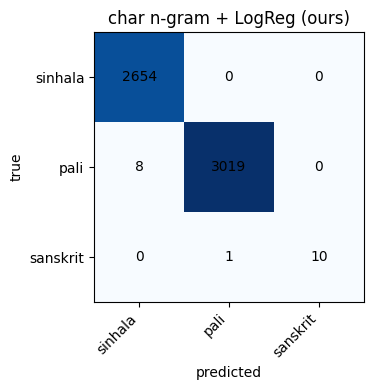

saved baseline model


In [47]:
from sklearn.feature_extraction.text import TfidfVectorizer
from sklearn.linear_model import LogisticRegression
import joblib

# character n-grams (2-4 chars): capture spelling / word-ending patterns that
# differ between the three languages even though they share the Sinhala script.
vectorizer = TfidfVectorizer(analyzer="char", ngram_range=(2, 4), max_features=20000)
X_train = vectorizer.fit_transform(train["text"])
X_test  = vectorizer.transform(test["text"])

clf = LogisticRegression(max_iter=1000, class_weight="balanced")
clf.fit(X_train, train["label"])

base_preds = clf.predict(X_test)
evaluate_model("char n-gram + LogReg (ours)", test["label"], base_preds)
show_confusion("char n-gram + LogReg (ours)", test["label"], base_preds)

# save for the Streamlit demo later
joblib.dump({"vectorizer": vectorizer, "clf": clf}, f"{OUTPUT_DIR}/baseline_charngram.joblib")
print("saved baseline model")


##Existing-tool baselines (the comparison)

These are ready-made LangID tools. They were built assuming *Sinhala script = Sinhala language*, so they have **no Pali or Sanskrit labels**. Anything they don't map to Sinhala (`si`) we count as `other`. Expect them to score near-zero on Pali and Sanskrit — that gap is the whole point of your benchmark.

In [48]:
def to_core_label(code):
    # existing tools only know 'si' among our three; everything else = other
    return {"si": "sinhala"}.get(code, "other")

# ---- fastText lid.176 ----
try:
    import fasttext, urllib.request
    MODEL_PATH = "lid.176.ftz"
    if not os.path.exists(MODEL_PATH):
        urllib.request.urlretrieve(
            "https://dl.fbaipublicfiles.com/fasttext/supervised-models/lid.176.ftz",
            MODEL_PATH)
    ft = fasttext.load_model(MODEL_PATH)

    def ft_predict(text):
        text = text.replace("\n", " ").strip()
        if not text:
            return "other"
        code = ft.predict(text)[0][0].replace("__label__", "")
        return to_core_label(code)

    ft_preds = [ft_predict(t) for t in test["text"]]
    evaluate_model("fastText lid.176 (existing)", test["label"], ft_preds,
                   note="off-the-shelf; no Pali/Sanskrit labels")
    show_confusion("fastText lid.176 (existing)", test["label"], ft_preds)
except Exception as e:
    print("fastText step skipped:", e)


fastText step skipped: Unable to avoid copy while creating an array as requested.
If using `np.array(obj, copy=False)` replace it with `np.asarray(obj)` to allow a copy when needed (no behavior change in NumPy 1.x).
For more details, see https://numpy.org/devdocs/numpy_2_0_migration_guide.html#adapting-to-changes-in-the-copy-keyword.



=== langdetect (existing) ===
              precision    recall  f1-score   support

     sinhala       0.00      0.00      0.00    2654.0
        pali       0.00      0.00      0.00    3027.0
    sanskrit       0.00      0.00      0.00      11.0

   micro avg       0.00      0.00      0.00    5692.0
   macro avg       0.00      0.00      0.00    5692.0
weighted avg       0.00      0.00      0.00    5692.0


Confusion matrix — langdetect (existing)
               pred_sinhala  pred_pali  pred_sanskrit  pred_other
true_sinhala              0          0              0        2654
true_pali                 0          0              0        3027
true_sanskrit             0          0              0          11
true_other                0          0              0           0


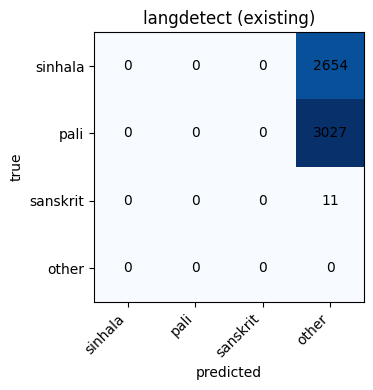

In [49]:
# ---- langdetect ----
try:
    from langdetect import detect, DetectorFactory
    DetectorFactory.seed = 0

    def ld_predict(text):
        text = text.strip()
        if not text:
            return "other"
        try:
            return to_core_label(detect(text))
        except Exception:
            return "other"

    ld_preds = [ld_predict(t) for t in test["text"]]
    evaluate_model("langdetect (existing)", test["label"], ld_preds,
                   note="off-the-shelf; no Pali/Sanskrit labels")
    show_confusion("langdetect (existing)", test["label"], ld_preds)
except Exception as e:
    print("langdetect step skipped:", e)


## 7. Results table (all models side by side)

How to read this for Monday:
- **accuracy** can look high for the existing tools too — but only because Sinhala dominates the data.
- Look at **F1_pali** and **F1_sanskrit**: the existing tools sit near **0**, while your char n-gram model is high.
- **macro_F1** averages the three languages equally, so it exposes the gap. That single number is your headline.

In [50]:
results_df = (pd.DataFrame(RESULTS)
              .sort_values("macro_F1", ascending=False)
              .reset_index(drop=True))
results_df.to_csv(f"{OUTPUT_DIR}/benchmark_results.csv", index=False)
results_df


,model,accuracy,macro_F1,F1_sinhala,F1_pali,F1_sanskrit,note
0,char n-gram + LogReg (ours),0.998,0.983,0.998,0.999,0.952,NaN
1,langdetect (existing),0.000,0.000,0.000,0.000,0.000,off-the-shelf; no Pali/Sanskrit labels


## 8. Next iterations (agile — add models here)

Each week, add ONE stronger model on the *same* split and let it drop into the table.

**Template** — train your model, predict on `test`, then:
```python
# my_preds = my_model.predict(test["text"])
# evaluate_model("char-CNN", test["label"], my_preds)
# show_confusion("char-CNN", test["label"], my_preds)
```

Suggested order:
1. ✅ char n-gram + LogReg (done)
2. Character-level neural net (CNN or GRU over characters)
3. Multilingual transformer (fine-tune XLM-RoBERTa) — needs a GPU

`val.csv` is for tuning hyperparameters; only touch `test.csv` for your final reported numbers.